# Artificial Non-Streaming Demo

This notebook mirrors the lean ZINC non-streaming demo, but uses an artificial NetworkX dataset generated in memory.

- source: cycle -> connector path -> star-ray graphs
- sample count: `DATASET_SIZE`
- fit mode: materialize generated graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import sys
from IPython.core.display import HTML
from pathlib import Path
import random
import warnings
import numpy as np

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'conditional_node_field_graph_generator').is_dir():
        repo_root = candidate.resolve()
        break
else:
    raise RuntimeError(
        'Could not locate the NodeField repository from the current working directory. '
        'Start Jupyter from the repo root or the notebooks directory.'
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator
from conditional_node_field_graph_generator.extensions.synthetic import generate_artificial_dataset


PyTorch version: 2.11.0+cu128
CUDA available: True


In [2]:
RANDOM_SEED = 42
DATASET_SIZE = 6000
CYCLE_LENGTH = 4
NUM_CYCLES = 1
PATH_LENGTH = 2
NUM_RAYS = 2
RAY_LENGTH = 2
NODE_ALPHABET_SIZE = 3
EDGE_ALPHABET_SIZE = 1
NODE_ALPHABET_KIND = 'int'
EDGE_ALPHABET_KIND = 'int'
COMPONENT_SPECIFIC_ALPHABETS = True
FIT_BATCH_SIZE = 128
MAXIMUM_EPOCHS = 350
LOSS_CURVES_PDF_EVERY_N_EPOCHS = 10
EMBEDDING_DIM = 64
CYCLE_COUNT_TOKEN = '' if NUM_CYCLES == 1 else f'-nc{NUM_CYCLES}'
MODEL_NAME = (
    f'artificial-cycle-path-star-n{DATASET_SIZE}'
    f'-c{CYCLE_LENGTH}{CYCLE_COUNT_TOKEN}-p{PATH_LENGTH}-r{NUM_RAYS}x{RAY_LENGTH}'
    f'-d{EMBEDDING_DIM}-b{FIT_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
)
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)




Saved artificial dataset config: artificial-cycle-path-star-n6000-c4-p2-r2x2-na3.yaml
Loaded 6000 artificial graphs into memory for non-streaming fit.
Node count min/median/max = 10/10/10
Edge count min/median/max = 10/10/10
Metadata: {'cycle_length': 4, 'num_cycles': 1, 'path_length': 2, 'num_rays': 2, 'ray_length': 2, 'node_alphabet_size': 3, 'edge_alphabet_size': 1, 'component_specific_alphabets': True, 'node_alphabets_by_component': {'cycle': [0, 1, 2], 'path': [3, 4, 5], 'star': [6, 7, 8]}, 'edge_alphabets_by_component': {'cycle': [0], 'path': [1], 'star': [2]}}
Configured graph generator model_name=artificial-cycle-path-star-n6000-c4-p2-r2x2-d64-b128-e350 model_dir=/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators
Training sample PDF: /cs0eth/home/fc334/code/NodeField/.artifacts/samples/artificial-cycle-path-star-n6000-c4-p2-r2x2-d64-b128-e350/training_samples.pdf


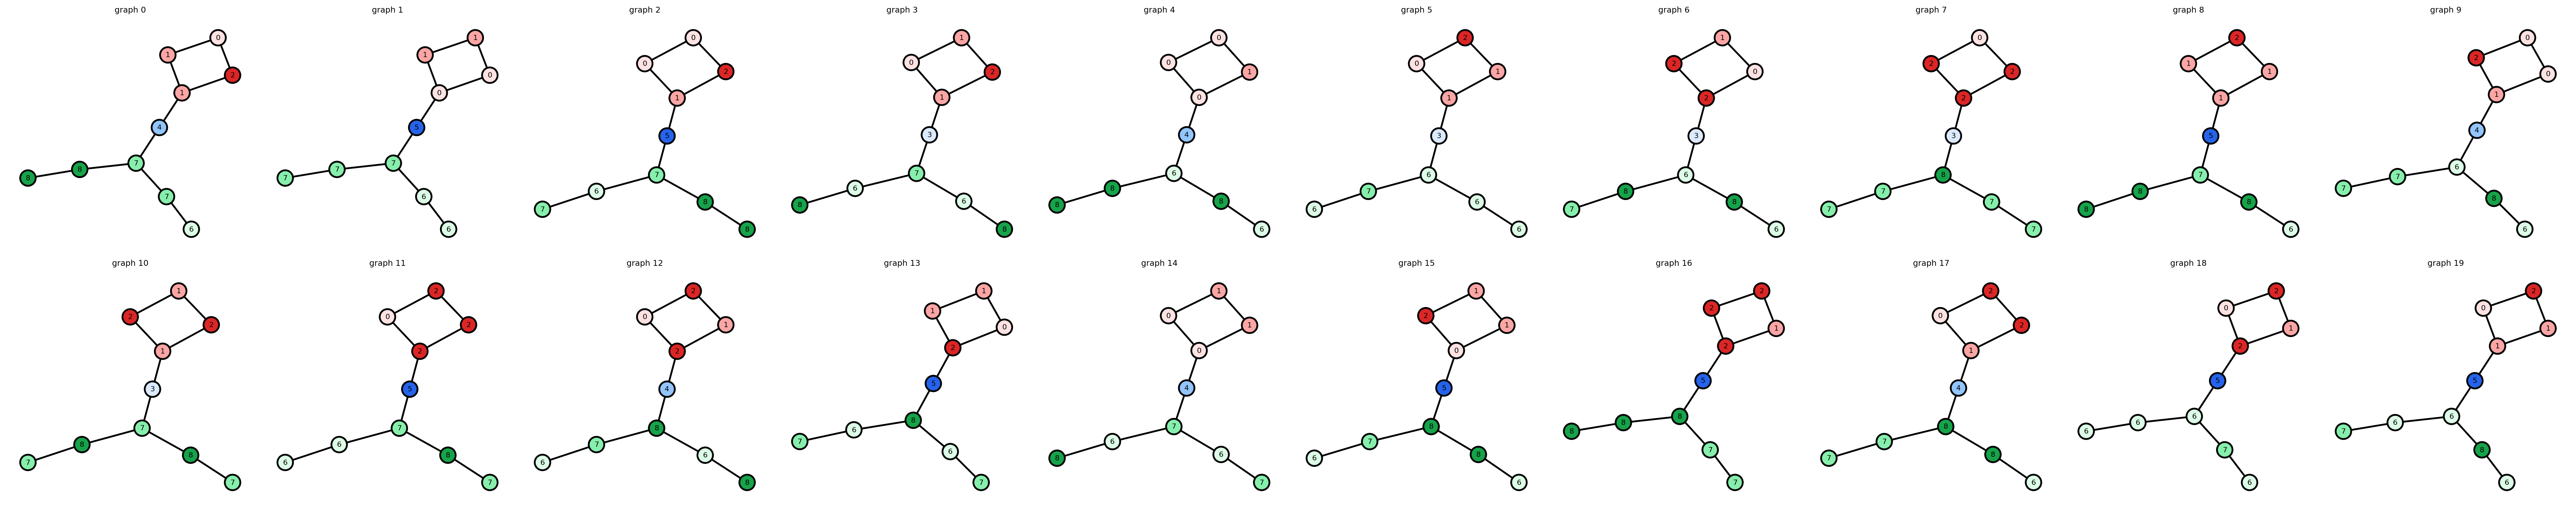

In [3]:
graphs, plot_artificial_graphs = generate_artificial_dataset(
    num_graphs=DATASET_SIZE,
    cycle_length=CYCLE_LENGTH,
    num_cycles=NUM_CYCLES,
    path_length=PATH_LENGTH,
    num_rays=NUM_RAYS,
    ray_length=RAY_LENGTH,
    node_alphabet_size=NODE_ALPHABET_SIZE,
    edge_alphabet_size=EDGE_ALPHABET_SIZE,
    node_alphabet_kind=NODE_ALPHABET_KIND,
    edge_alphabet_kind=EDGE_ALPHABET_KIND,
    component_specific_alphabets=COMPONENT_SPECIFIC_ALPHABETS,
    seed=RANDOM_SEED,
)

node_counts = np.array([graph.number_of_nodes() for graph in graphs])
edge_counts = np.array([graph.number_of_edges() for graph in graphs])
print(f'Loaded {len(graphs)} artificial graphs into memory for non-streaming fit.')
print(f'Node count min/median/max = {node_counts.min()}/{np.median(node_counts):.0f}/{node_counts.max()}')
print(f'Edge count min/median/max = {edge_counts.min()}/{np.median(edge_counts):.0f}/{edge_counts.max()}')
print('Metadata:', graphs[0].graph['metadata'])

plot_artificial_graphs(
    graphs[:20],
    n_cols=10,
    titles=[f'graph {idx}' for idx in range(20)],
)

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=3,
    transformer_attention_head_count=4,
    locality_horizon=2,
    sparse_supervision_mask_ratio=0.9,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.loss_curves_pdf_every_n_epochs = LOSS_CURVES_PDF_EVERY_N_EPOCHS
def render_artificial_graphs(decoded_graphs, **kwargs):
    graph_list = list(decoded_graphs)
    titles = kwargs.get('titles')
    plot_artificial_graphs(
        graph_list,
        n_cols=max(1, min(7, len(graph_list))),
        titles=titles,
    )


graph_generator.graph_decoder.diagnostic_graph_renderer = render_artificial_graphs

TRAINING_PROGRESS_PDF_PATH = ARTIFACT_ROOT / 'samples' / MODEL_NAME / 'training_samples.pdf'
print(f'Training sample PDF: {TRAINING_PROGRESS_PDF_PATH}')


In [ ]:
%%time
graph_generator.fit(
    graphs,
    sample_training_progress=True,
    sample_training_progress_n_samples=3,
    sample_training_progress_every_n_epochs=5,
    sample_training_progress_pdf_path=TRAINING_PROGRESS_PDF_PATH,
    sample_training_progress_plot_fn=plot_artificial_graphs,
)
print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


Fit target model_name=artificial-cycle-path-star-n6000-c4-p2-r2x2-d64-b128-e350 model_dir=/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators
Fitting model on 6000 graphs
Fitted node embedding SVD: 2048 -> 64.
Fitted graph embedding SVD: 2048 -> 64.
Fitting feasibility estimator on 6000 graphs
Finished fitting feasibility estimator in 0m 48.9s
Supervision plan:
  node_labels: mode=learned, enabled. 9 node labels detected.
  edge_labels: mode=learned, enabled. 3 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=learned, enabled, horizon=2. Use horizon-2 locality as auxiliary regularization.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 360000 pairs (50.00%) from 720000 total pairs (pos=240000, neg=480000, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=120000,

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA A2') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


epoch 1: finished generator snapshot in 0.19s
epoch 2: finished generator snapshot in 0.29s
epoch 3: finished generator snapshot in 0.20s
epoch 4: finished generator snapshot in 0.18s
epoch 5: finished generator snapshot in 0.18s
epoch 5: sampling training progress graphs
epoch 5: appended training sample PDF page to /cs0eth/home/fc334/code/NodeField/.artifacts/samples/artificial-cycle-path-star-n6000-c4-p2-r2x2-d64-b128-e350/training_samples.pdf
epoch 6: finished generator snapshot in 0.19s
epoch 7: finished generator snapshot in 0.19s
epoch 8: finished generator snapshot in 0.19s
epoch 9: finished generator snapshot in 0.19s
Epoch 10/350 | ETA 0h 23m 35s:
  train total=   32.962 | node_field    23.697 [71.9%] |        deg   0.76258 [2.3%] | node_label    1.5249 [4.6%] | edge_label   0.39573 [1.2%]
  val   total=   31.828 | node_field    23.588 [74.1%] |        deg   0.64795 [2.0%] | node_label    1.2148 [3.8%] | edge_label   0.28619 [0.9%]
  train                 |       edge    1.38

In [ ]:
# Optional reload path for a previously saved artificial non-streaming model.
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)

list_saved_graph_generators(SAVED_GENERATOR_ROOT)
MODEL_FILENAME = f'{MODEL_NAME}.pkl'
graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)


In [ ]:
n_samples = 8
sample_variants = graph_generator._sample_training_decode_variants(n_samples)

for variant_key, title_prefix in (
    ('raw', 'raw'),
    ('ilp', 'ilp'),
    ('oracle', 'oracle ilp'),
):
    variant_samples = sample_variants[variant_key]
    plot_artificial_graphs(
        variant_samples,
        n_cols=n_samples,
        titles=[f'{title_prefix} {idx}' for idx in range(len(variant_samples))],
    )

In [ ]:
if graph_generator.feasibility_estimator is None:
    print('Feasibility estimator is unavailable in this environment; skipping filtered sampling.')
else:
    filtered_samples = graph_generator.sample(
        n_samples=n_samples,
        apply_feasibility_filtering=True,
    )
    plot_artificial_graphs(
        filtered_samples,
        n_cols=n_samples,
        titles=[f'filtered {idx}' for idx in range(len(filtered_samples))],
    )
